<a href="https://colab.research.google.com/github/manasa7695-dotcom/ML-projects/blob/main/svmtask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Get list of all dataset names
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


1: Data Understanding


 Load dataset


In [ ]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


 Display shape, columns, and sample records


In [ ]:
df.shape

(891, 15)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


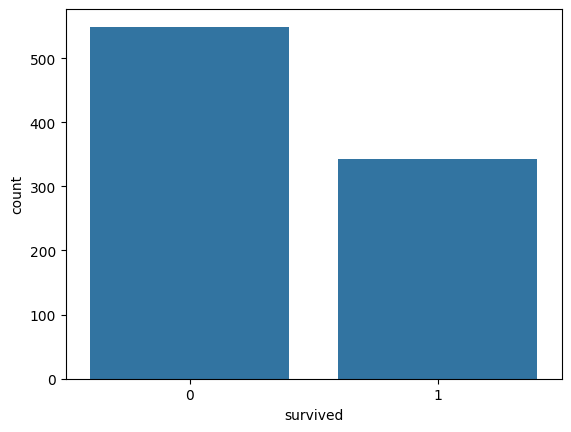

In [ ]:
sns.countplot(x='survived',data=df)
plt.show()

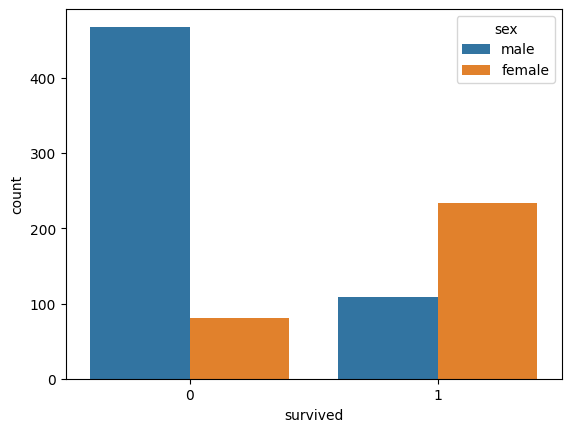

In [ ]:
sns.countplot(x='survived',hue='sex',data=df)
plt.show()

 Identify input features and target variable


In [ ]:
x=df.drop('survived',axis=1)
# convert all column names to string
x.columns = x.columns.astype(str)
y=df['survived']

2: Data Preprocessing


 Handle missing values


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


 Encode categorical labels

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:

sex=pd.get_dummies(df['sex'],drop_first=True,dtype=int)

In [ ]:
embark = pd.get_dummies(df['embarked'],drop_first=True,dtype=int)

In [ ]:
pclass = pd.get_dummies(df['pclass'],drop_first=True,dtype=int)

In [ ]:
who = pd.get_dummies(df['who'],drop_first=True,dtype=int)


In [ ]:
df = pd.get_dummies(df, columns=['embark_town'], drop_first=True, dtype=int)

In [ ]:
df['age'].fillna(df['age'].mean(),inplace=True)

/tmp/ipykernel_1546/1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [ ]:
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [ ]:
df=pd.concat([df,sex,embark,pclass,who],axis=1)

In [ ]:
df = df.drop(['deck', 'alive','sex','who','embarked'], axis=1)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
df['class']=encoder.fit_transform(df[['class']])

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
age,0
sibsp,0
parch,0
fare,0
class,0
adult_male,0
alone,0
embark_town_Queenstown,0


In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
age,float64
sibsp,int64
parch,int64
fare,float64
class,float64
adult_male,int64
alone,int64
embark_town_Queenstown,int64


In [ ]:
df.head()

,survived,pclass,age,sibsp,parch,fare,class,adult_male,alone,embark_town_Queenstown,embark_town_Southampton,male,Q,S,2,3,man,woman
0,0,3,22.0,1,0,7.2500,2.0,1,0,0,1,1,0,1,0,1,1,0
1,1,1,38.0,1,0,71.2833,0.0,0,0,0,0,0,0,0,0,0,0,1
2,1,3,26.0,0,0,7.9250,2.0,0,1,0,1,0,0,1,0,1,0,1
3,1,1,35.0,1,0,53.1000,0.0,0,0,0,1,0,0,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,2.0,1,1,0,1,1,0,1,0,1,1,0


In [ ]:
x=df.drop('survived',axis=1)
# convert all column names to string
x.columns = x.columns.astype(str)
y=df['survived']

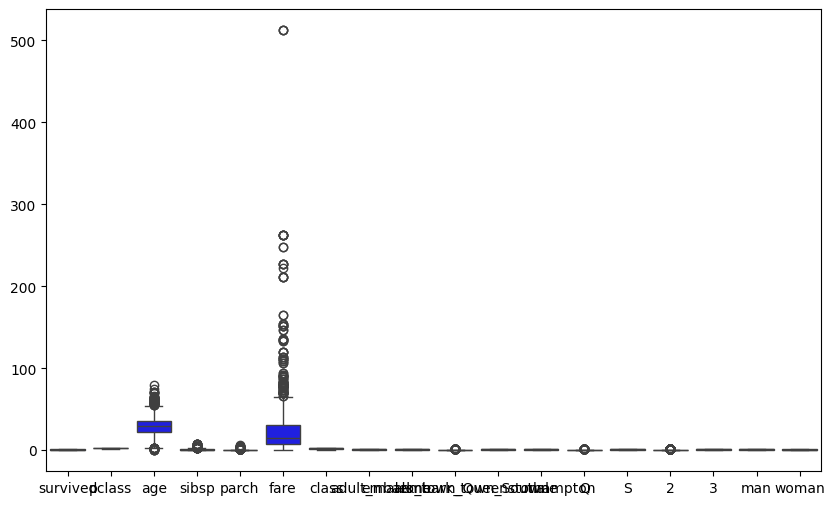

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,color='blue')
plt.show()

In [ ]:
for col in ['age', 'sibsp', 'parch', 'fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

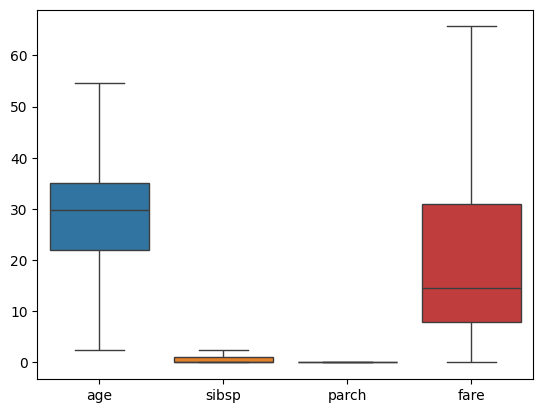

In [ ]:
sns.boxplot(data=df[['age','sibsp','parch','fare']])
plt.show()

In [ ]:
print(df.shape)

(891, 18)


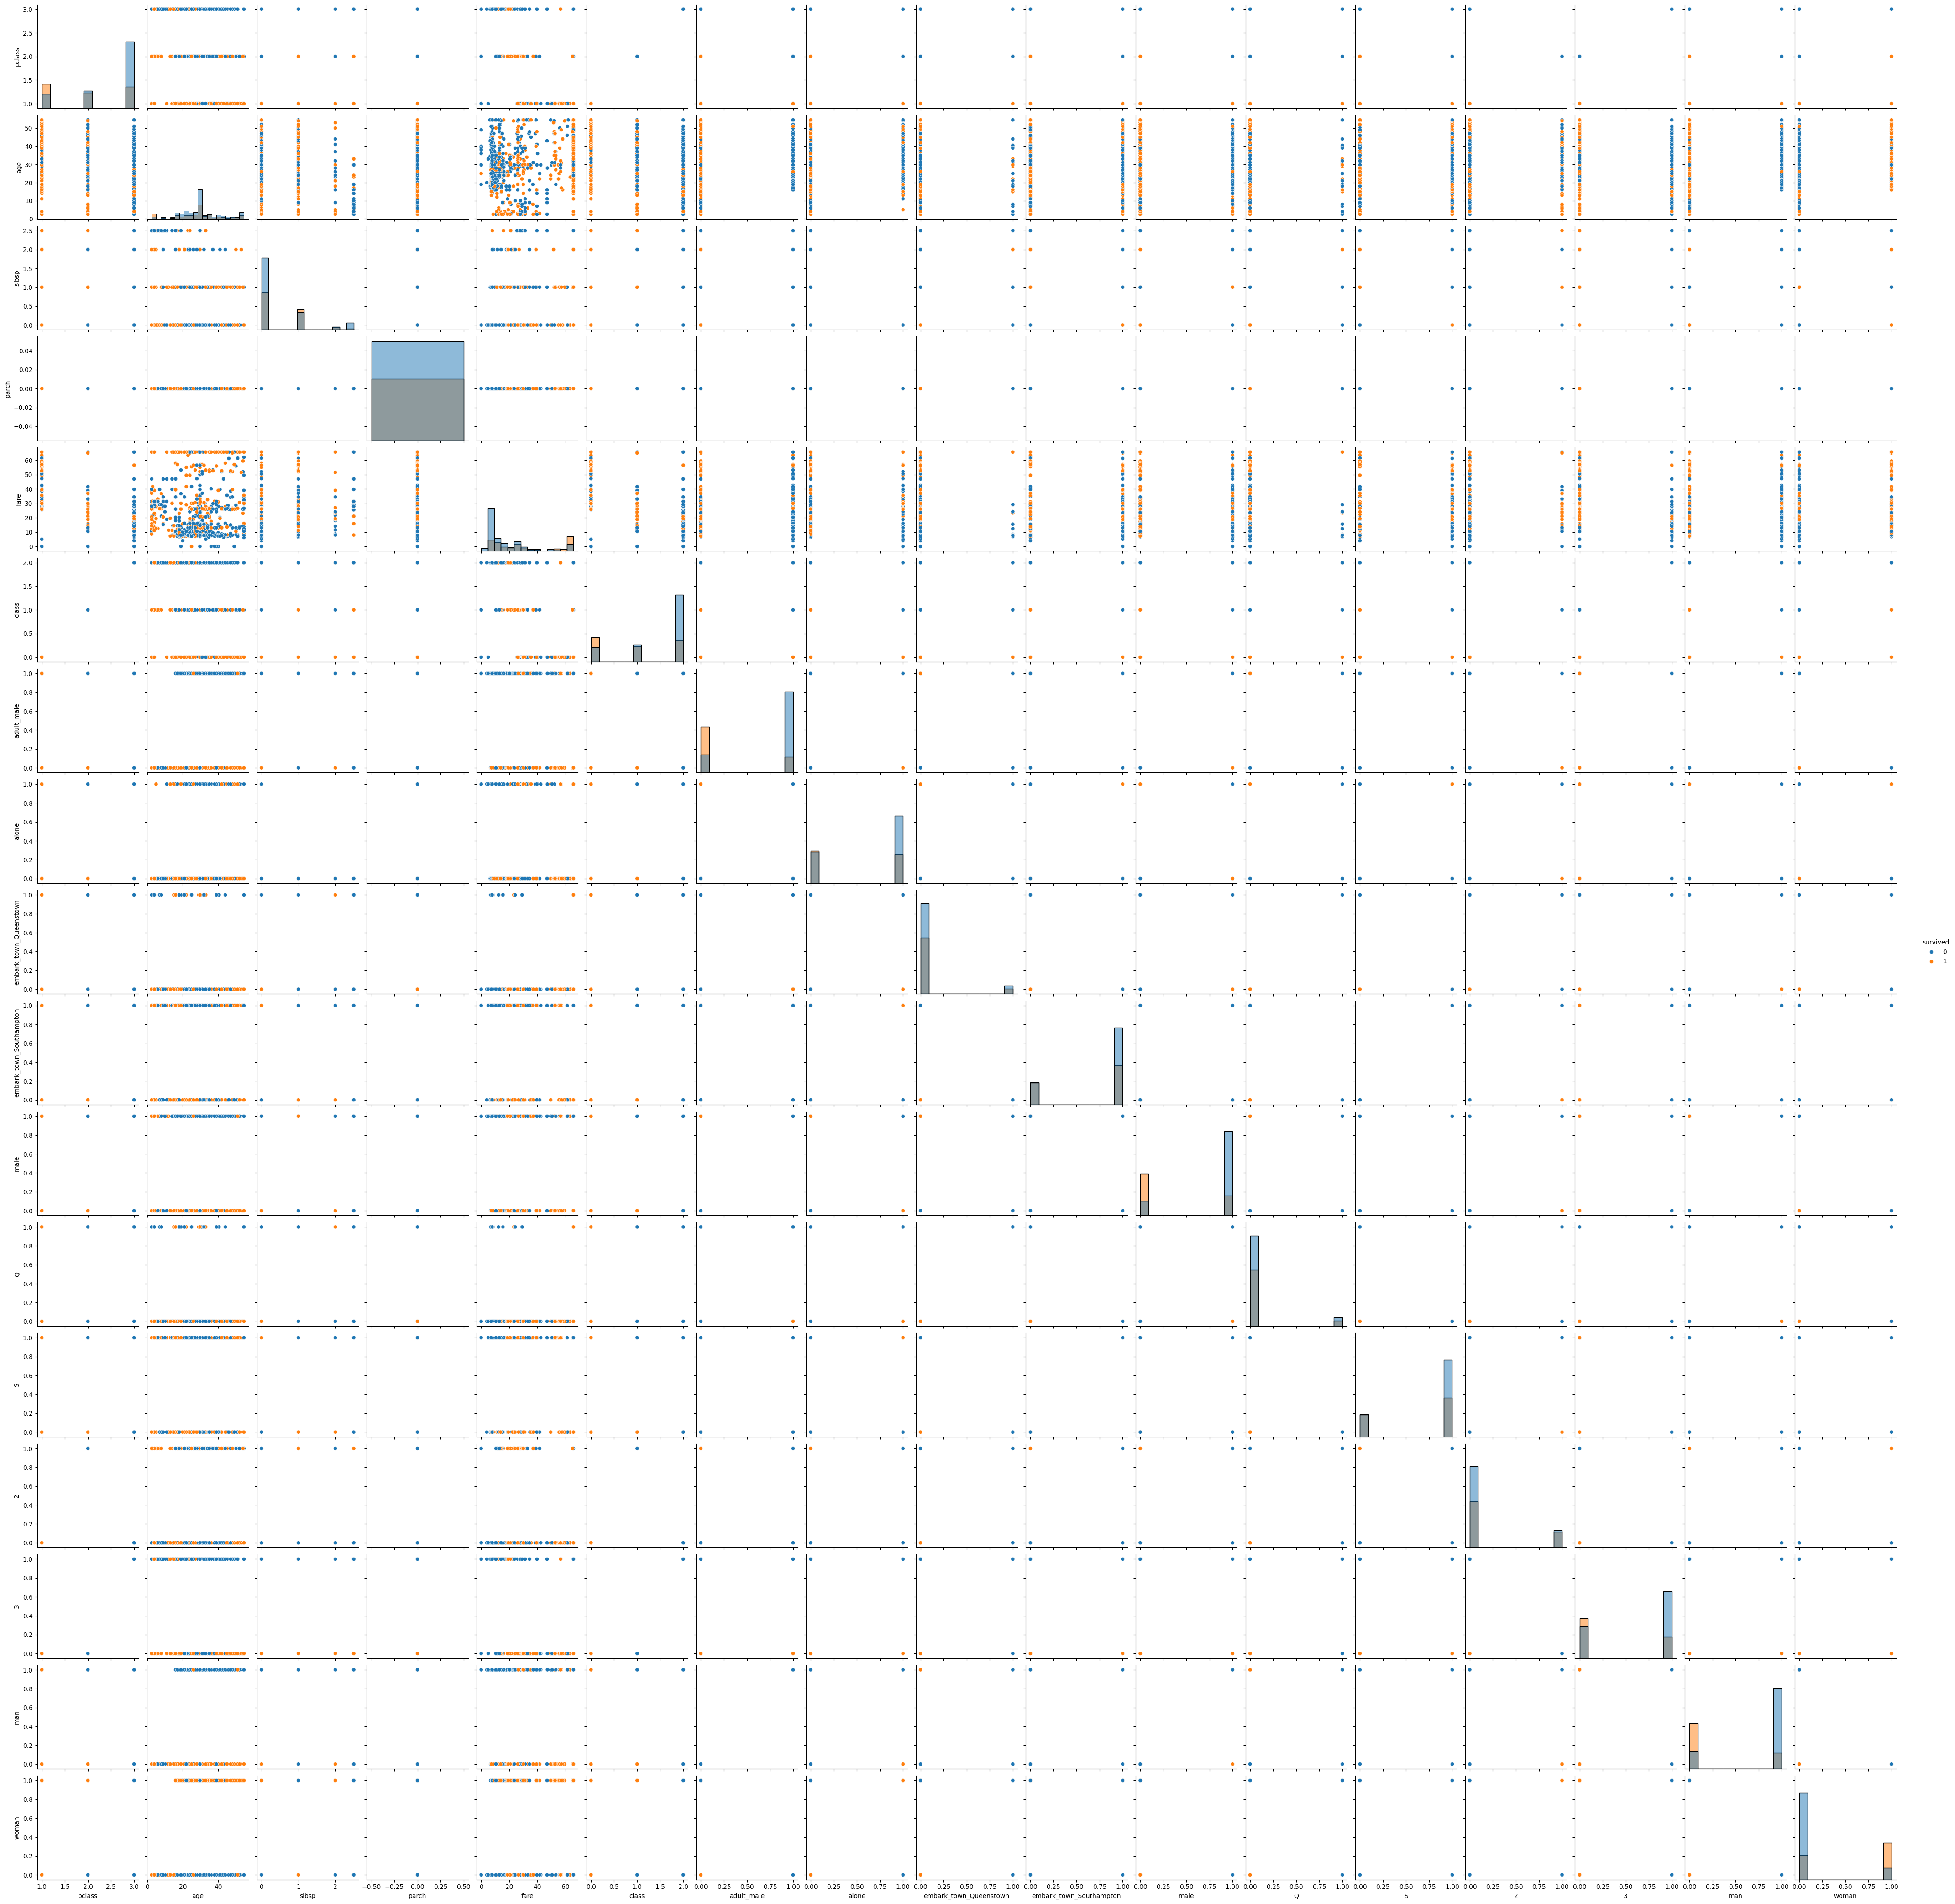

In [ ]:
sns.pairplot(df,hue='survived',diag_kind='hist')
plt.show()

 Apply :feature scaling (StandardScaler)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)

 Split dataset


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split( x,y,test_size=0.2,random_state=1)

3: Linear SVM Model


 Train Linear SVM


In [ ]:
from sklearn.svm import SVC
C=1
model=SVC(kernel='linear',C=C, class_weight='balanced')
model.fit(x_train,y_train)
pred_y=model.predict(x_test)

 Predict test values


In [ ]:
print(pred_y)

[1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 0
 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


Evaluate using:

1. Accuracy
2. Confusion Matrix
3. Classification Report








In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred_y))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       106
           1       0.79      0.66      0.72        73

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(confusion_matrix(y_test,pred_y))
print(accuracy_score(y_test,pred_y))

[[93 13]
 [25 48]]
0.7877094972067039


4: Polynomial Kernel SVM


In [ ]:
from sklearn.svm import SVC
C=1
poly=SVC(kernel='poly',C=C,degree=3,gamma='auto')
poly.fit(x_train,y_train)
pred_y=poly.predict(x_test)

Evaluate using:

1. Accuracy
2. Confusion Matrix
3. Classification Report








In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(confusion_matrix(y_test,pred_y))
print(accuracy_score(y_test,pred_y))

[[100   6]
 [ 33  40]]
0.7821229050279329


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred_y))

              precision    recall  f1-score   support

           0       0.75      0.94      0.84       106
           1       0.87      0.55      0.67        73

    accuracy                           0.78       179
   macro avg       0.81      0.75      0.75       179
weighted avg       0.80      0.78      0.77       179



5: RBF Kernel SVM


In [ ]:
from sklearn.svm import SVC
C=20
poly=SVC(kernel='rbf',C=C,gamma=0.1)
poly.fit(x_train,y_train)
pred_y=poly.predict(x_test)

Evaluate using:

1. Accuracy
2. Confusion Matrix
3. Classification Report








In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(confusion_matrix(y_test,pred_y))
print(accuracy_score(y_test,pred_y))

[[98  8]
 [29 44]]
0.7932960893854749


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred_y))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84       106
           1       0.85      0.60      0.70        73

    accuracy                           0.79       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Score: 0.845543189205161


6: Model Comparison




1. Compare Linear vs Polynomial vs RBF SVM
2. Tabulate accuracy scores
3. Identify best-performing kernel



In [ ]:
models = {'linear': SVC(kernel='linear', C=1),
    'poly': SVC(kernel='poly', degree=3, C=10),
    'rbf': SVC(kernel='rbf', C=10, gamma=0.1)}
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
print(pd.DataFrame(results, columns=['Kernel', 'Accuracy']))

   Kernel  Accuracy
0  linear  0.787709
1    poly  0.776536
2     rbf  0.793296


7: Visualization


 Plot decision boundaries (for 2 features)




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


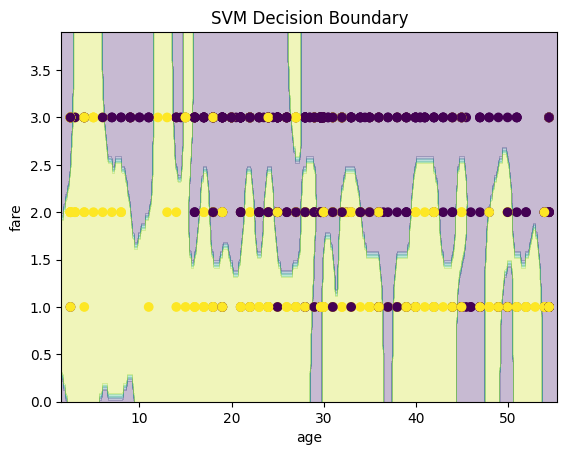

In [ ]:
import numpy as np
X = df[['age','pclass']].dropna()
y = df.loc[X.index, 'survived']
# Train SVM
from sklearn import svm
svm_clf = svm.SVC(kernel='rbf', gamma=0.9, C=20)
svm_clf.fit(X, y)
# Meshgrid + decision boundary
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y)
plt.xlabel('age')
plt.ylabel('fare')
plt.title("SVM Decision Boundary")
plt.show()


 Plot confusion matrices for each model


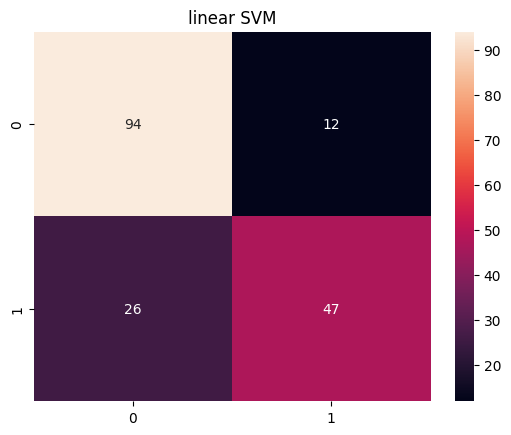

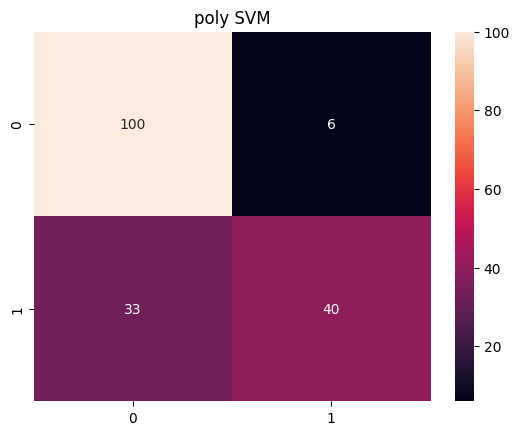

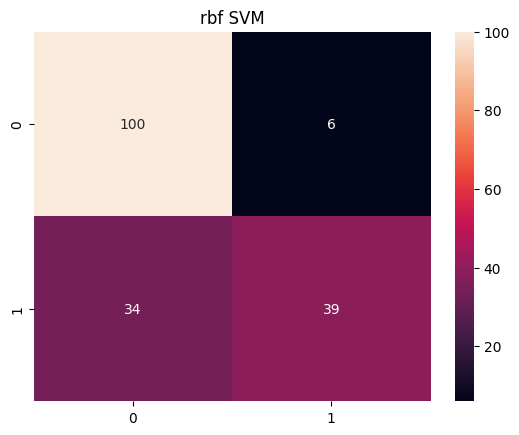

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for k in ['linear', 'poly', 'rbf']:
    model = SVC(kernel=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d')
    plt.title(f'{k} SVM')
    plt.show()
